In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Titanic_train.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df_test = pd.read_csv('Titanic_test.csv')
df_test.shape

(418, 11)

In [4]:
df_test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [10]:
df['Age_missing'] = df['Age'].isnull().astype(int)
df.groupby('Pclass')['Age_missing'].mean()

Pclass
1    0.138889
2    0.059783
3    0.276986
Name: Age_missing, dtype: float64

In [11]:
df.groupby('Sex')['Age_missing'].mean()

Sex
female    0.168790
male      0.214905
Name: Age_missing, dtype: float64

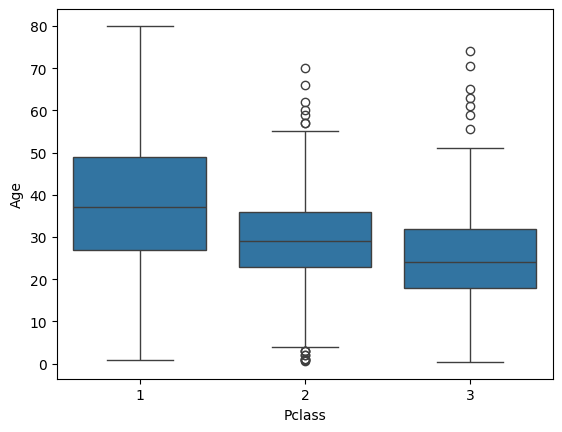

In [12]:
sns.boxplot(x='Pclass', y = 'Age',data= df )
plt.show()

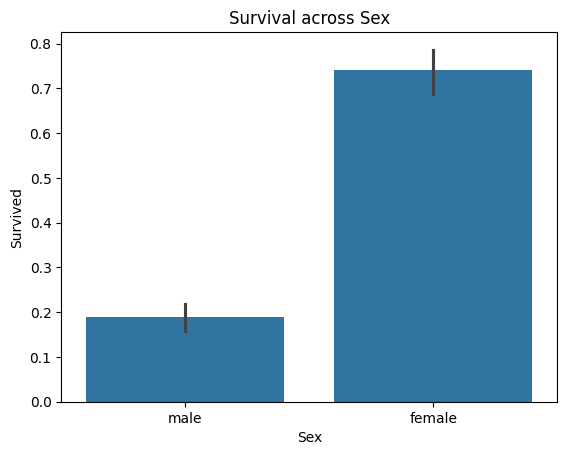

In [13]:
sns.barplot(x='Sex',y='Survived',data=df)
plt.title('Survival across Sex')
plt.show()

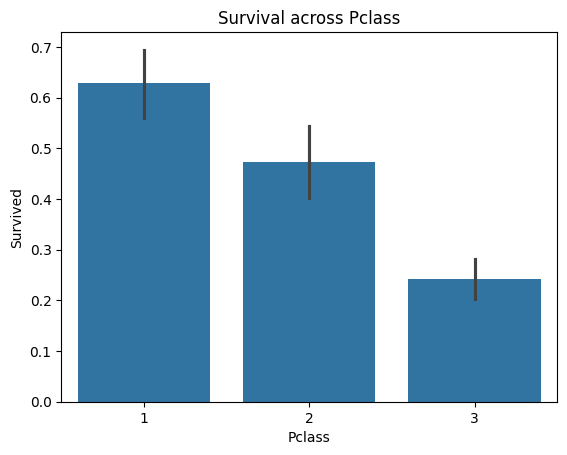

In [14]:
sns.barplot(x='Pclass',y='Survived',data=df)
plt.title('Survival across Pclass')
plt.show()

we know that sex is a strong predictor for survival due to female surviving rate being highest, Pclass also affects survival chance as higher class passengers may get prioritized first than the lower classes. Age distribution also differed across the classes which may indicate that age distribution and missingness depends on passenger class which may be systematic missingness.

# preprocessing

In [15]:
df.groupby('Pclass')['Age'].median() 

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

In [16]:
df_expected_age = df.groupby('Pclass')['Age'].transform('median')
df['Age']= df['Age'].fillna(df_expected_age)

In [17]:
df['Age'].isnull().sum()

0

In [18]:
df =df.drop(columns=['Cabin','Ticket'])

In [19]:
df =df.drop(columns=['Name','PassengerId'])

In [20]:
df.dtypes

Survived         int64
Pclass           int64
Sex             object
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked        object
Age_missing      int32
dtype: object

these columns is less important in this context and it also had so many missing values >50 percent so it would only bias our model if we keep it so dropping it might be a good decisiion. as for ticket it contains alphanumeric data and is contextually less important

In [21]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [22]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [23]:
df['Embarked'].isnull().sum()

0

In [24]:
# one Hot encoding the categorical columns
df =pd.get_dummies(df,columns=['Sex','Embarked','Pclass'], drop_first=True)

In [25]:
df

,Survived,Age,SibSp,Parch,Fare,Age_missing,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,22.0,1,0,7.2500,0,True,False,True,False,True
1,1,38.0,1,0,71.2833,0,False,False,False,False,False
2,1,26.0,0,0,7.9250,0,False,False,True,False,True
3,1,35.0,1,0,53.1000,0,False,False,True,False,False
4,0,35.0,0,0,8.0500,0,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,27.0,0,0,13.0000,0,True,False,True,True,False
887,1,19.0,0,0,30.0000,0,False,False,True,False,False
888,0,24.0,1,2,23.4500,1,False,False,True,False,True
889,1,26.0,0,0,30.0000,0,True,False,False,False,False


# Train Test Split

In [26]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print(X.shape)
print(y.shape)


(891, 10)
(891,)


In [27]:
from  sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X,y, 
                                                  test_size=0.2,
                                                  random_state=42,
                                                  stratify=y)

print(X_train.shape,y_val.shape)

(712, 10) (179,)


In [28]:
X_train.dtypes

Age            float64
SibSp            int64
Parch            int64
Fare           float64
Age_missing      int32
Sex_male          bool
Embarked_Q        bool
Embarked_S        bool
Pclass_2          bool
Pclass_3          bool
dtype: object

# Model training - Baseline

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [30]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [32]:
y_pred = lr_model.predict(X_val)

In [33]:
y_pred

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0], dtype=int64)

# Model Evaluation -Baseline

In [35]:
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))


Accuracy: 0.7988826815642458
Precision: 0.7894736842105263
Recall: 0.6521739130434783
F1 Score: 0.7142857142857143


although the model has the accuracy of nearly 80 percent we cannot trust the mdoel due to the recall score being the weakest of all. we cannot trust a model that has recall lower , false positives are deadly in real world use cases.

# XGBoost -Model

In [36]:
! pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
from xgboost import XGBClassifier

In [38]:
xgb_model = XGBClassifier(n_estimators =200,
                         max_depth = 4,
                         learning_rate = 0.05,
                         random_state = 42)

xgb_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [39]:
y_pred_xgb = xgb_model.predict(X_val)

In [40]:
y_pred_xgb

array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [41]:
print("Accuracy:", accuracy_score(y_val, y_pred_xgb))
print("Precision:", precision_score(y_val, y_pred_xgb))
print("Recall:", recall_score(y_val, y_pred_xgb))
print("F1 Score:", f1_score(y_val, y_pred_xgb))

Accuracy: 0.7932960893854749
Precision: 0.7857142857142857
Recall: 0.6376811594202898
F1 Score: 0.704


the accuracy and overall score here is  lower than the baseline logistic regression model, since the dataset is small here the logistic regression model is well suited for such tasks. xgboost model shines when the dataset is large and has complex feature interaction. the simple model such as logistic regression can do much better job at such small range of data. on top of that the featurs are mostly linear. we might get better result hyperparamerter tunning in xgb model.

# LightGBM model

In [42]:
! pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
    --------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -- ------------------------------------- 0.1/1.5 MB 1.2 MB/s eta 0:00:02
   ----- ---------------------------------- 0.2/1.5 MB 1.8 MB/s eta 0:00:01
   --------- ------------------------------ 0.3/1.5 MB 1.9 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.5 MB 2.2 MB/s eta 0:00:01
   ----------------- ---------------------- 0.6/1.5 MB 2.4 MB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.5 MB 2.3 MB/s eta 0:00:01
   ------------------------- -------------- 0.9/1.5 MB 2.4 MB/s eta 0:00:01
   ----------------------------- ---------- 1.1/1.5 MB 2.6 MB/s eta 0:00:01
   --------------------------------- ------ 1.2/1.5 MB 2.5 MB/s eta 0:00:01
   ------------------------------------- -- 1.4/1.5 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------  1.4/1.5 MB 2.6 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=-1,
            random_state= 42)

lgb_model.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 208
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [44]:
y_pred_lgb=lgb_model.predict(X_val)

In [45]:
y_pred_lgb

array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0], dtype=int64)

In [46]:
print("Accuracy:", accuracy_score(y_val, y_pred_lgb))
print("Precision:", precision_score(y_val, y_pred_lgb))
print("Recall:", recall_score(y_val, y_pred_lgb))
print("F1 Score:", f1_score(y_val, y_pred_lgb))

Accuracy: 0.7988826815642458
Precision: 0.7538461538461538
Recall: 0.7101449275362319
F1 Score: 0.7313432835820896


# Model Tuning

In [47]:
# XGboost Tuning

from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators':[100,200,300],
    'max_depth':[3,4,5],
    'learning_rate':[0.01,0.05,0.1]
}

grid_xgb = GridSearchCV(
            XGBClassifier(random_state=42),
            param_grid_xgb,
            cv = 5,
            scoring ='f1',
            n_jobs= -1)

grid_xgb.fit(X_train,y_train)

print('Best_parameters:', grid_xgb.best_params_)

Best_parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}


In [48]:
xgb_tuned = XGBClassifier(n_estimators =200,
                         max_depth = 4,
                         learning_rate = 0.01,
                         random_state = 42)

xgb_tuned.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [49]:
y_pred_xgb_tuned = xgb_tuned.predict(X_val)

In [50]:
y_pred_xgb_tuned

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [51]:
print("Accuracy:", accuracy_score(y_val, y_pred_xgb_tuned))
print("Precision:", precision_score(y_val, y_pred_xgb_tuned))
print("Recall:", recall_score(y_val, y_pred_xgb_tuned))
print("F1 Score:", f1_score(y_val, y_pred_xgb_tuned))

Accuracy: 0.8044692737430168
Precision: 0.8695652173913043
Recall: 0.5797101449275363
F1 Score: 0.6956521739130435


even after the tuning of the model the recall dropped to all time lowest here.. it can be tradeoff here.

In [52]:
#lightGBM tuning
param_grid_lgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63]
}

grid_lgb = GridSearchCV(
    LGBMClassifier(random_state=42),
    param_grid_lgb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lgb.fit(X_train, y_train)

print("Best params:", grid_lgb.best_params_)


[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 208
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [53]:
lgb_tuned = XGBClassifier(n_estimators =300,
                         learning_rate = 0.01,
                         num_leaves = 31,
                         random_state = 42)

lgb_tuned.fit(X_train,y_train)

C:\Users\Shree Hari\AppData\Roaming\Python\Python310\site-packages\xgboost\core.py:158: UserWarning: [15:41:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "num_leaves" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_leaves=31,
              num_parallel_tree=None, ...)

In [54]:
y_pred_lgb_tuned = lgb_tuned.predict(X_val)

In [55]:
y_pred_lgb_tuned

array([0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [56]:
print("Accuracy:", accuracy_score(y_val, y_pred_lgb_tuned))
print("Precision:", precision_score(y_val, y_pred_lgb_tuned))
print("Recall:", recall_score(y_val, y_pred_lgb_tuned))
print("F1 Score:", f1_score(y_val, y_pred_lgb_tuned))


Accuracy: 0.8100558659217877
Precision: 0.8301886792452831
Recall: 0.6376811594202898
F1 Score: 0.7213114754098361


# Conclusion

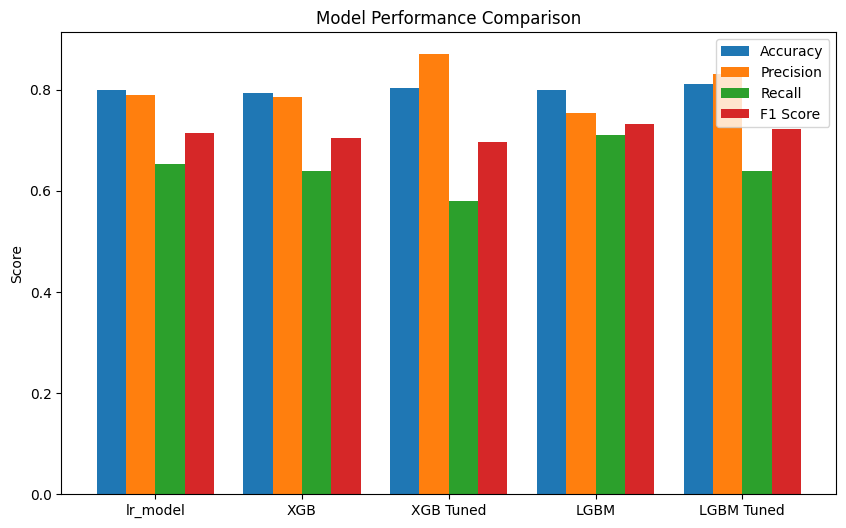

In [59]:
models = ["lr_model", "XGB", "XGB Tuned", "LGBM", "LGBM Tuned"]

accuracy = [0.799, 0.793, 0.804, 0.799, 0.810]
precision = [0.789, 0.786, 0.870, 0.754, 0.830]
recall = [0.652, 0.638, 0.580, 0.710, 0.638]
f1 = [0.714, 0.704, 0.696, 0.731, 0.721]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1, width, label="F1 Score")

plt.xticks(x, models)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.legend()

plt.show()


LightGBM performed best overall on the Titanic dataset.
After tuning, it achieved the highest accuracy (≈81%) and maintained a good balance between precision and recall, giving strong overall performance.
Logistic regression was a strong baseline model and Xgboost acheived the highest precision after tuning, but lightGBM provided the best overall balance across metrics.

Logistic Regression is a strong baseline for small, structured datasets.Boosting models are useful for capturing hidden feature interactions.

Model selection should depend on the business goal:

If avoiding false positives is critical : XGBoost (high precision)

If detecting as many positives as possible is important : LightGBM (better recall & balance)